# Scalability experiments

In [1]:
import pandas as pd

df = pd.read_csv("results/partial/scalabilityApproaches_all_methods_v1_partial.csv")

In [131]:
from pathlib import Path
import pandas as pd

df = pd.DataFrame()
for x in Path("results/remote").glob("*K*_n*.csv"):
    with open(x) as f:
        if len(f.readlines()):
            df = pd.concat([df, pd.read_csv(x)])

In [132]:
for x in df.columns:
    print(x)

risk
K
n
seed
gamma
alpha
epsilon
epsilon_scr
kappa
tau
max_candidates
n_screen_starts
n_support_starts
screen_maxiter
support_maxiter
stochastic_max_iter
stochastic_minibatch_size
methods
mcp_success
mcp_time_s
mcp_eta
mcp_regret1
mcp_regret2
mcp_has_profile
mcp_error
mcp_solver
mcp_candidate_index
mcp_support_eta
mcp_screen_eta
mcp_support_violation
mcp_residual_norm
mcp_objective
mcp_iterations
mcp_best_certificate_eta
screened_dual_success
screened_dual_time_s
screened_dual_eta
screened_dual_regret1
screened_dual_regret2
screened_dual_has_profile
screened_dual_error
screened_dual_solver
screened_dual_candidate_index
screened_dual_support_eta
screened_dual_screen_eta
screened_dual_support_violation
screened_dual_residual_norm
screened_dual_objective
screened_dual_iterations
screened_dual_best_certificate_eta
action_dual_success
action_dual_time_s
action_dual_eta
action_dual_regret1
action_dual_regret2
action_dual_has_profile
action_dual_error
action_dual_solver
action_dual_candidate

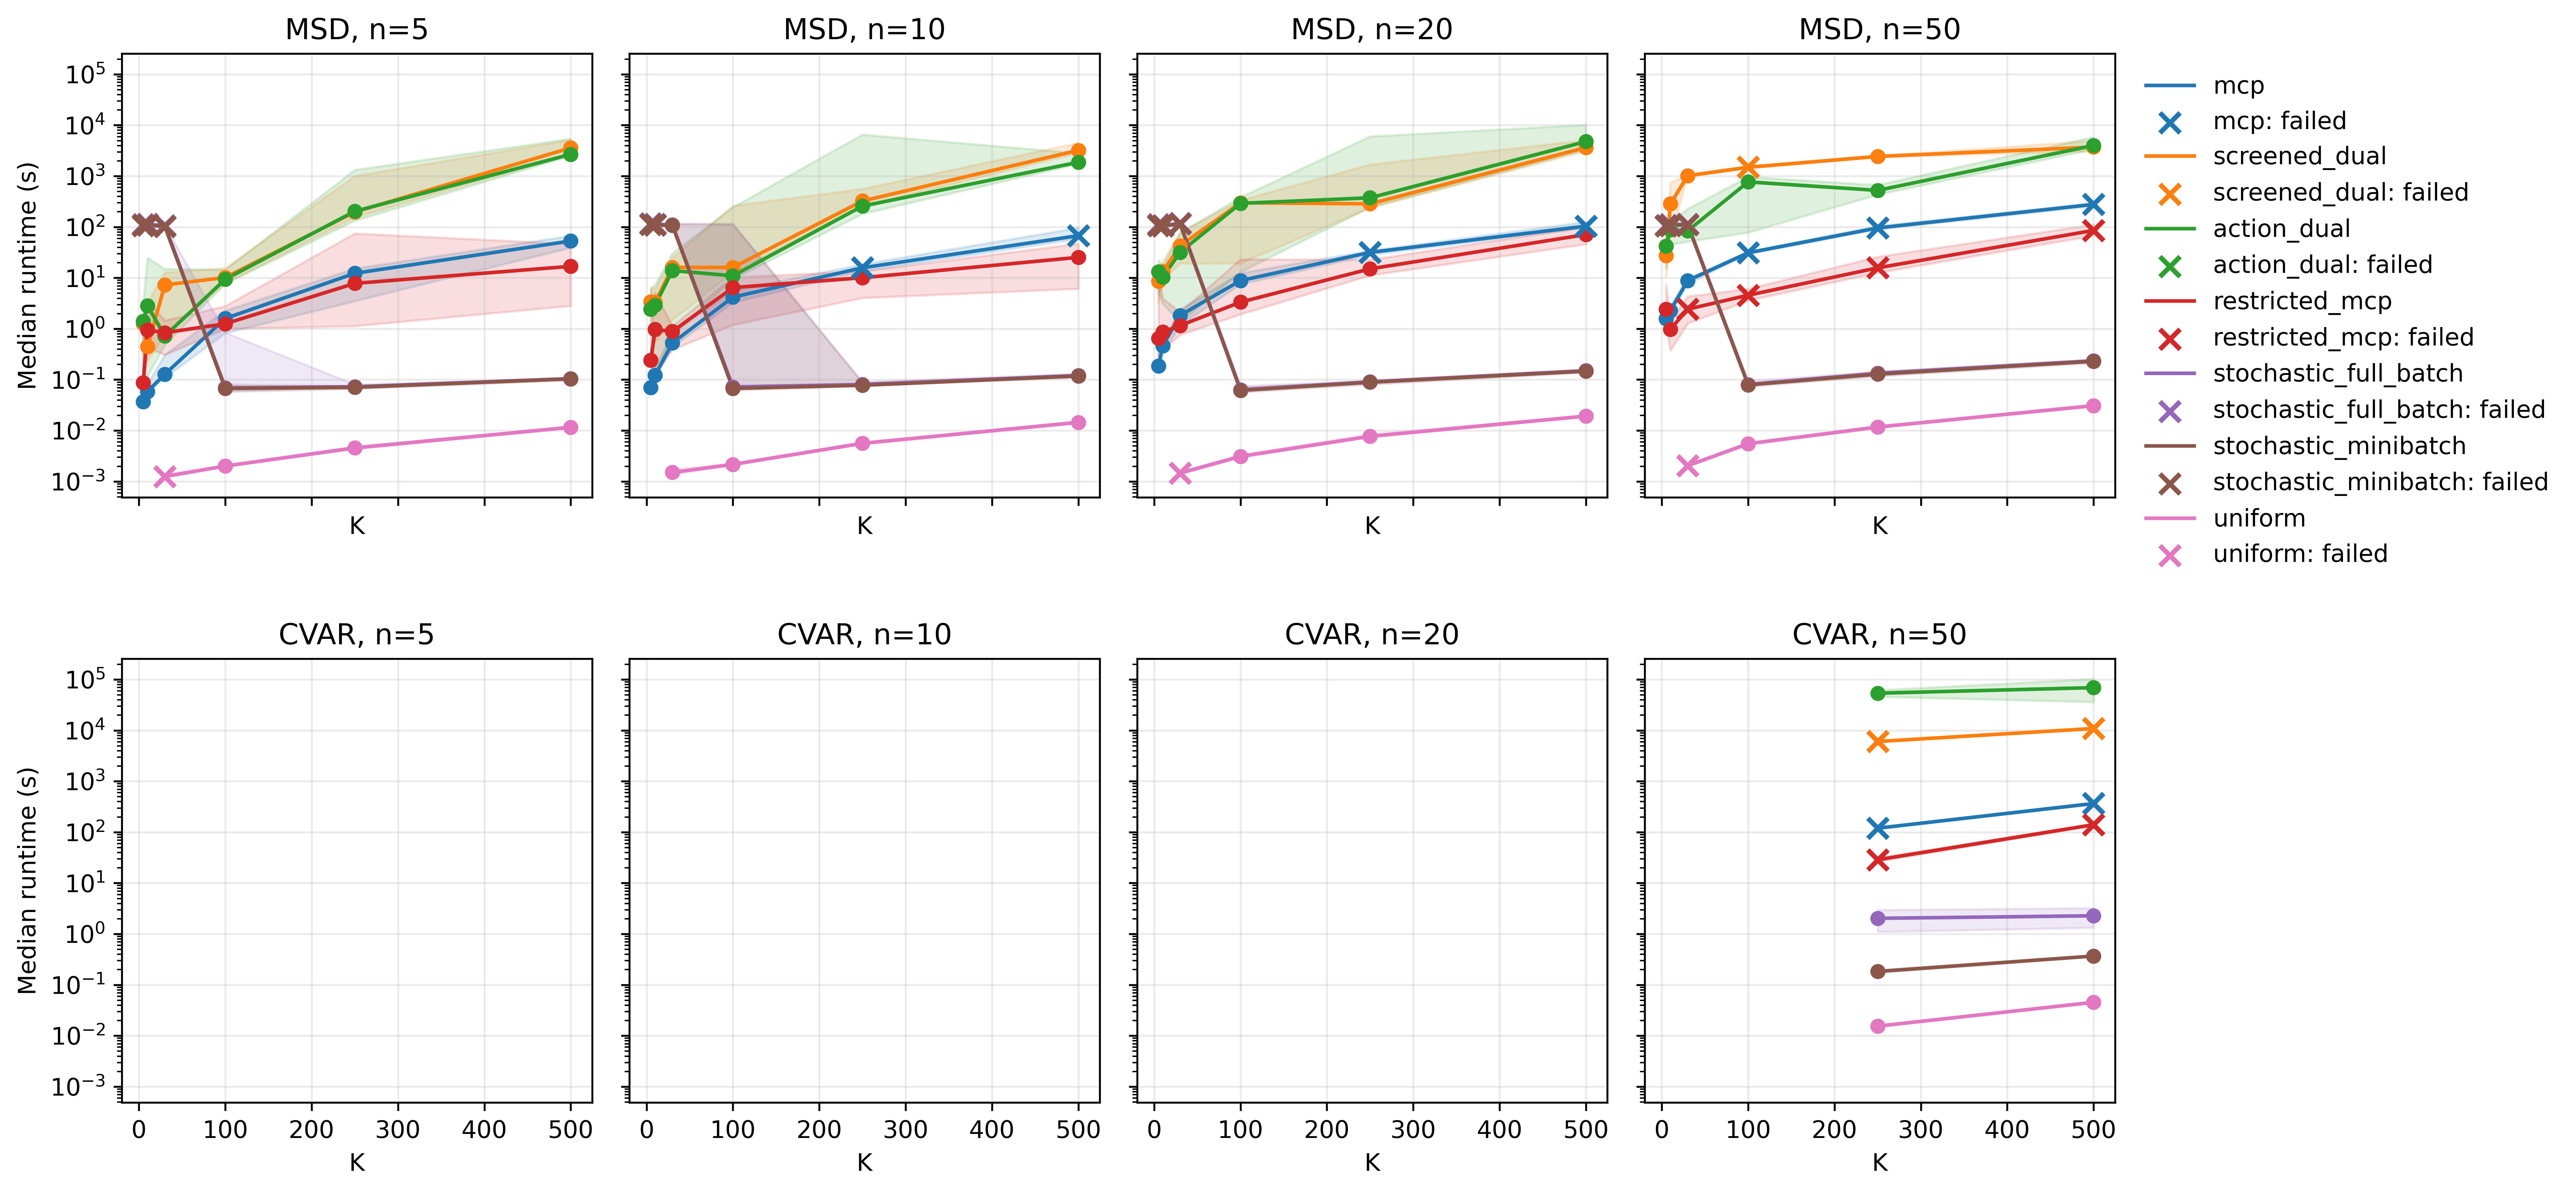

In [133]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        ).sort_values("K")

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = method_s.groupby("K", as_index=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_time_median": (f"{method}_time_s", "median"),
                    f"{method}_time_q25": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_time_q75": (
                        f"{method}_time_s",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_time_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_time_q25"],
                method_df[f"{method}_time_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_time_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_time_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median runtime (s)")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

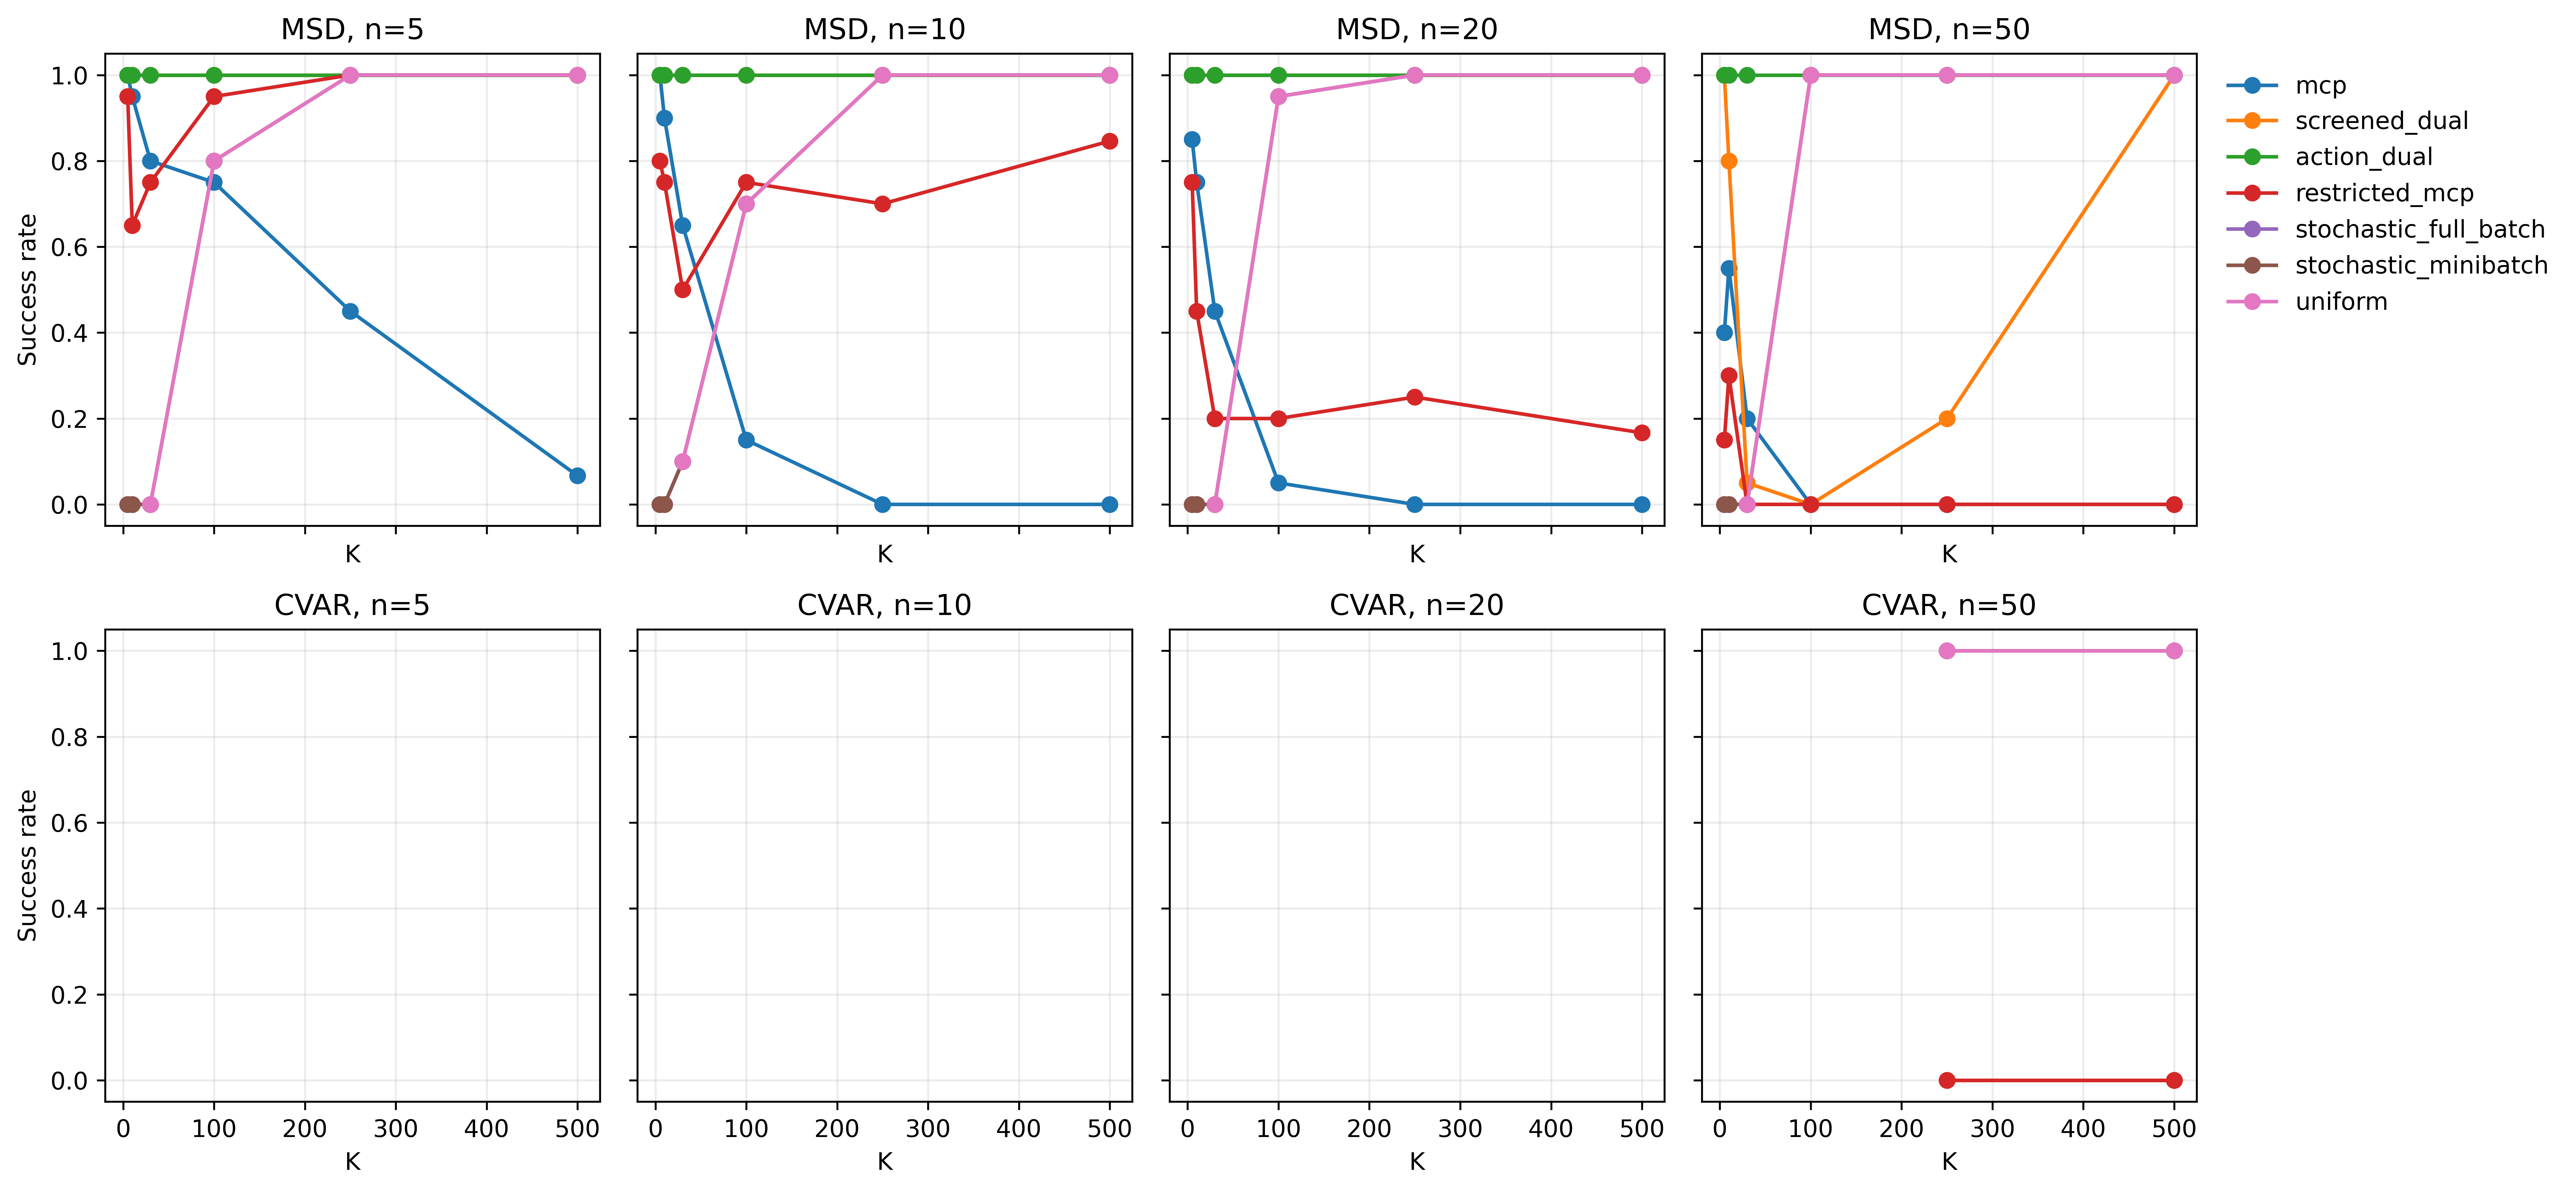

In [134]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)]
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        )

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = (
                method_s.groupby("K", as_index=False)
                .agg(
                    **{
                        f"{method}_reps": ("seed", "count"),
                        f"{method}_succ_n": (f"{method}_success", "sum"),
                    }
                )
                .sort_values("K")
            )

            if method_df.empty:
                continue

            method_df[f"{method}_succ_rate"] = (
                method_df[f"{method}_succ_n"] / method_df[f"{method}_reps"]
            )

            ax.plot(
                method_df["K"],
                method_df[f"{method}_succ_rate"],
                "o-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )

        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel("Success rate")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

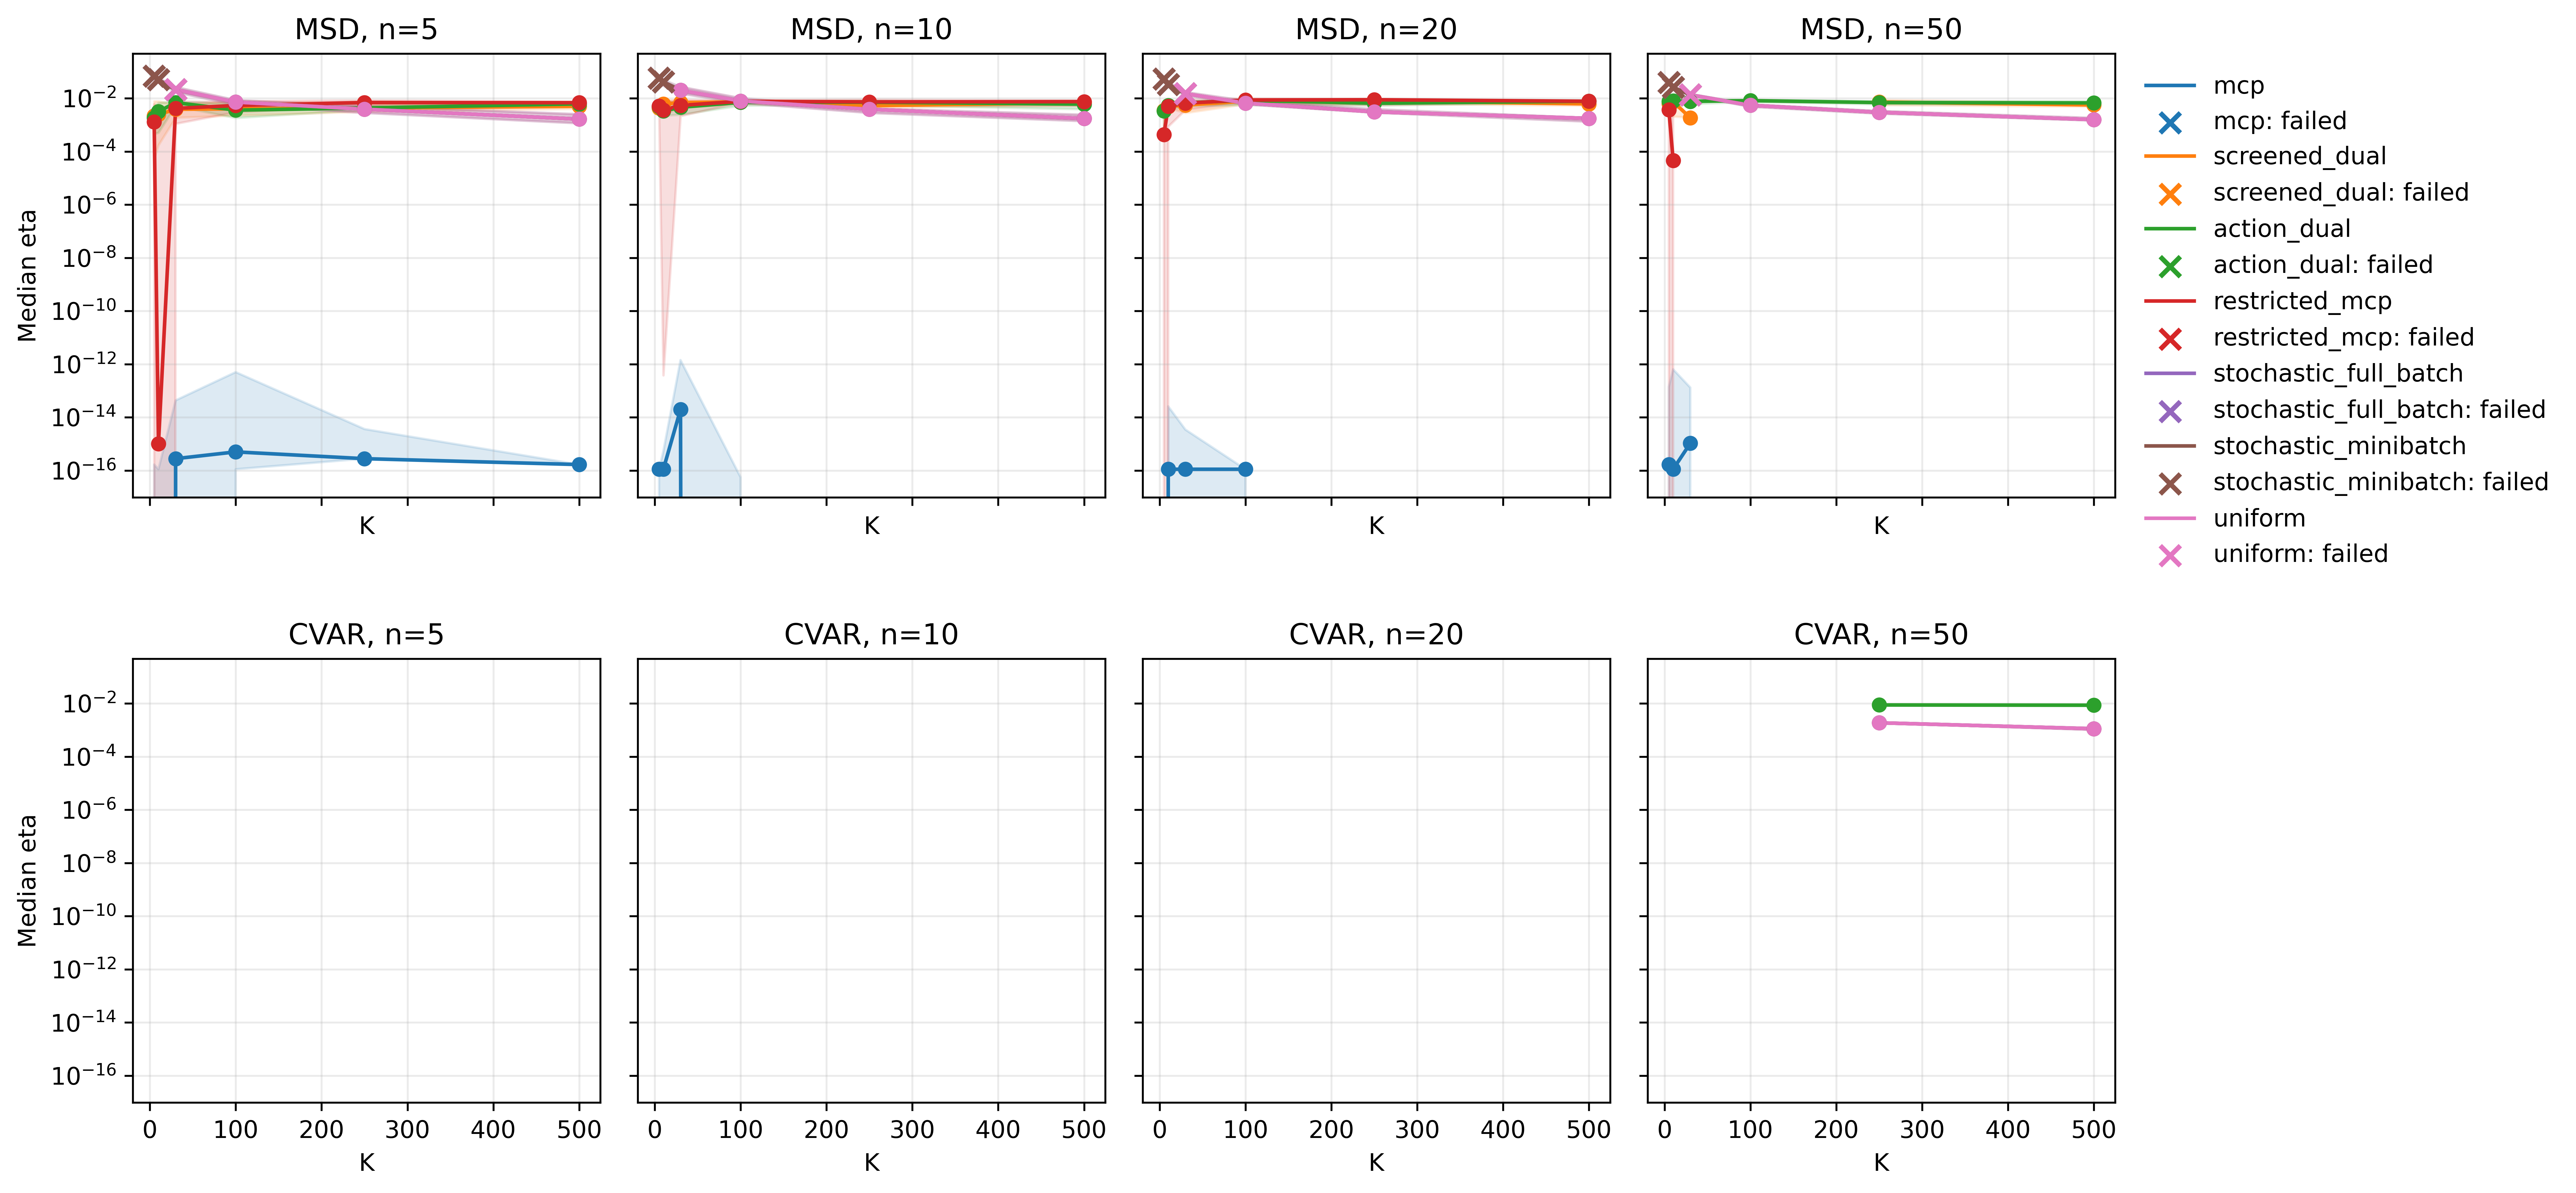

In [136]:
import matplotlib.pyplot as plt

K_grid = [5, 10, 30, 100, 250, 500]
n_grid = [5, 10, 20, 50]
risk_grid = ["msd", "cvar"]
uniform_df = pd.read_csv("results/uniform_profile_baseline.csv")

fig, axes = plt.subplots(
    len(risk_grid),
    len(n_grid),
    figsize=(15, 7),
    dpi=600,
    sharey=True,
    sharex=True,
)

methods = [m.strip() for m in df["methods"].iloc[0].split(",")]
if "uniform" not in methods:
    methods = methods + ["uniform"]
cmap = plt.get_cmap("tab10")
color_dict = {m: cmap(i % cmap.N) for i, m in enumerate(methods)}

for row, risk in enumerate(risk_grid):
    for col, n in enumerate(n_grid):
        ax = axes[row, col]
        s = df[(df["n"] == n) & (df["risk"] == risk)].sort_values("K")
        uniform_s = uniform_df.merge(
            s[["risk", "K", "n", "seed"]].drop_duplicates(),
            on=["risk", "K", "n", "seed"],
            how="inner",
        ).sort_values("K")

        for method in methods:
            method_s = uniform_s if method == "uniform" else s
            method_df = method_s.groupby("K", as_index=False, dropna=False).agg(
                **{
                    f"{method}_reps": ("seed", "count"),
                    f"{method}_eta_median": (f"{method}_eta", "median"),
                    f"{method}_eta_q25": (
                        f"{method}_eta",
                        lambda x: x.quantile(0.25),
                    ),
                    f"{method}_eta_q75": (
                        f"{method}_eta",
                        lambda x: x.quantile(0.75),
                    ),
                    f"{method}_succ_n": (f"{method}_success", "sum"),
                }
            )

            if method_df.empty:
                continue

            method_zero = method_df[f"{method}_succ_n"] == 0

            ax.plot(
                method_df["K"],
                method_df[f"{method}_eta_median"],
                "-",
                label=method if row == 0 and col == len(n_grid) - 1 else "_nolegend_",
                color=color_dict[method],
            )
            ax.fill_between(
                method_df["K"],
                method_df[f"{method}_eta_q25"],
                method_df[f"{method}_eta_q75"],
                alpha=0.15,
                label="_nolegend_",
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[~method_zero, "K"],
                method_df.loc[~method_zero, f"{method}_eta_median"],
                marker="o",
                s=28,
                zorder=4,
                color=color_dict[method],
            )
            ax.scatter(
                method_df.loc[method_zero, "K"],
                method_df.loc[method_zero, f"{method}_eta_median"],
                marker="x",
                s=70,
                linewidths=2.0,
                label=(
                    f"{method}: failed"
                    if row == 0 and col == len(n_grid) - 1
                    else "_nolegend_"
                ),
                zorder=5,
                color=color_dict[method],
            )

        ax.set_yscale("log")
        ax.set_title(f"{risk.upper()}, n={n}")
        ax.set_xlabel("K")
        ax.grid(alpha=0.25)

    axes[row, 0].set_ylabel(f"Median eta")

axes[0, -1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Hyperparameter tuning using pilots for stochastic algorithms

In [139]:
import pandas as pd

summary = pd.read_csv("results/stochastic/pilot_summary_v2.csv")
history = pd.read_csv("results/stochastic/pilot_history_v2.csv")

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_eta_history(history, K, n, method):
    h = history[
        (history["K"] == K) & (history["n"] == n) & (history["method"] == method)
    ].copy()

    if h.empty:
        return None

    config = ["entropy_kappa", "step_size"]
    groups = config + (["seed"] if "seed" in h.columns else [])

    h = h.sort_values(groups + ["iteration"])
    h["best_eta"] = h.groupby(groups)["eta"].cummin()

    g = sns.relplot(
        data=h,
        x="iteration",
        y="best_eta",
        # row="entropy_kappa",
        col="step_size",
        hue="entropy_kappa",
        kind="line",
        estimator="median",
        errorbar=("pi", 50),  # interquartile range if multiple seeds
        palette="viridis",
        height=2.6,
        aspect=1.25,
        facet_kws={"sharex": True, "sharey": True},
    )

    for ax in g.axes.flat:
        # ax.axhline(1e-3, color="black", linestyle="--", linewidth=1)
        ax.grid(alpha=0.2)

    g.set_axis_labels("Iteration", "Best certified eta")
    g.set_titles(r"step_size=${col_name}$")
    g.fig.suptitle(f"{method}: K={K}, n={n}", y=1.02)

    return g

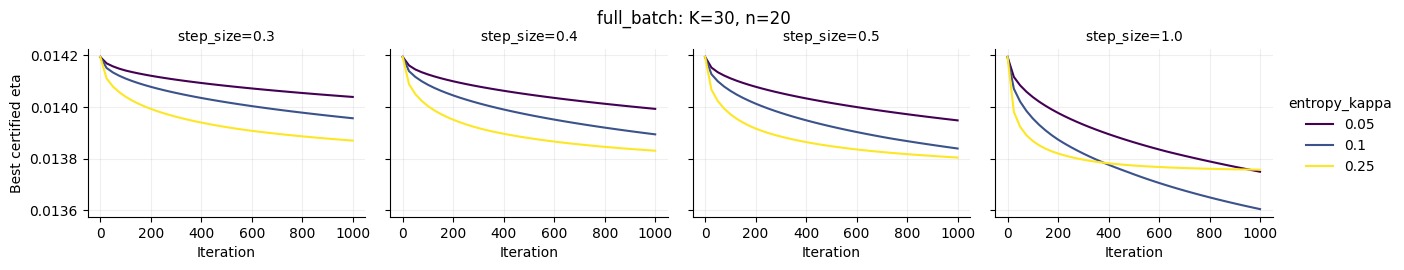

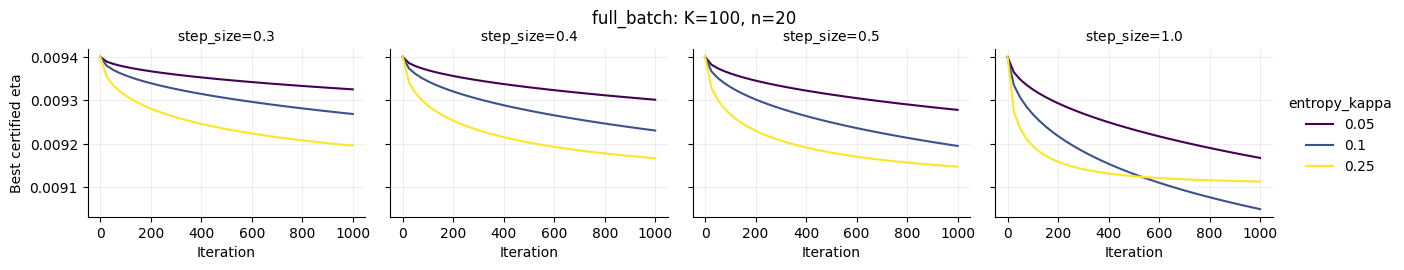

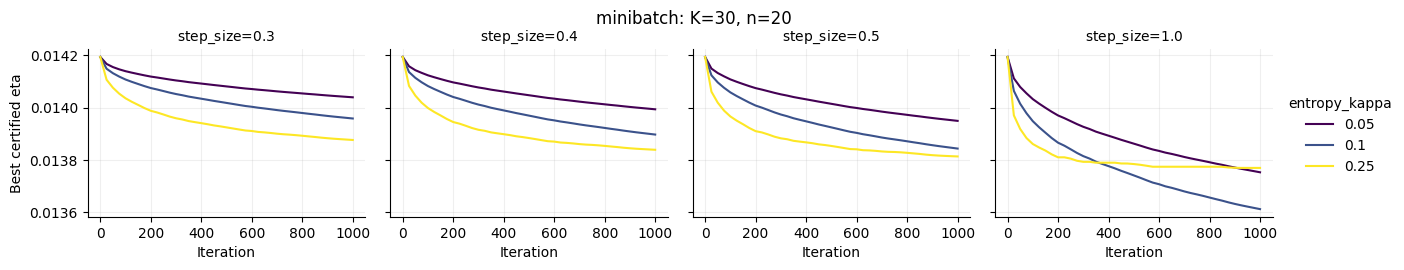

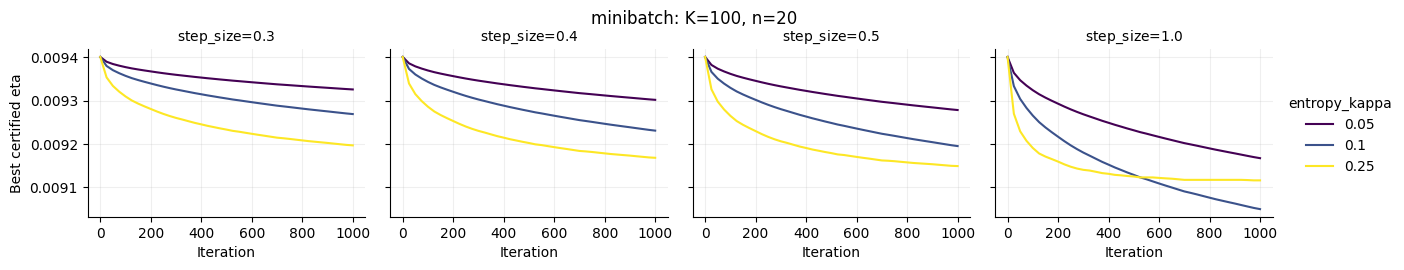

In [158]:
combinations = (
    history[["K", "n", "method"]].drop_duplicates().sort_values(["method", "K", "n"])
)

for row in combinations.itertuples(index=False):
    g = plot_eta_history(
        history,
        K=row.K,
        n=row.n,
        method=row.method,
    )
    if g is not None:
        plt.show()

In [161]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_eta_improvement(history, K, n, method):

    h = history[
        (history["K"] == K) & (history["n"] == n) & (history["method"] == method)
    ].copy()
    config = ["entropy_kappa", "smoothing_tau", "step_size"]
    groups = config + ["seed"]

    h = h.sort_values(groups + ["iteration"])
    h["best_eta"] = h.groupby(groups)["eta"].cummin()
    h["initial_eta"] = h.groupby(groups)["eta"].transform("first")
    h["eta_improvement_pct"] = (
        100 * (h["initial_eta"] - h["best_eta"]) / h["initial_eta"]
    )

    g = sns.relplot(
        data=h,
        x="iteration",
        y="eta_improvement_pct",
        # row="entropy_kappa",
        col="step_size",
        hue="entropy_kappa",
        kind="line",
        palette="viridis",
        height=2.6,
        aspect=1.25,
    )

    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)
        ax.grid(alpha=0.2)

    g.set_axis_labels("Iteration", "Improvement over uniform (%)")
    g.set_titles(r"$\tau={col_name}$")
    g.fig.suptitle(f"{method}: K={K}, n={n}", y=1.02)

    plt.show()

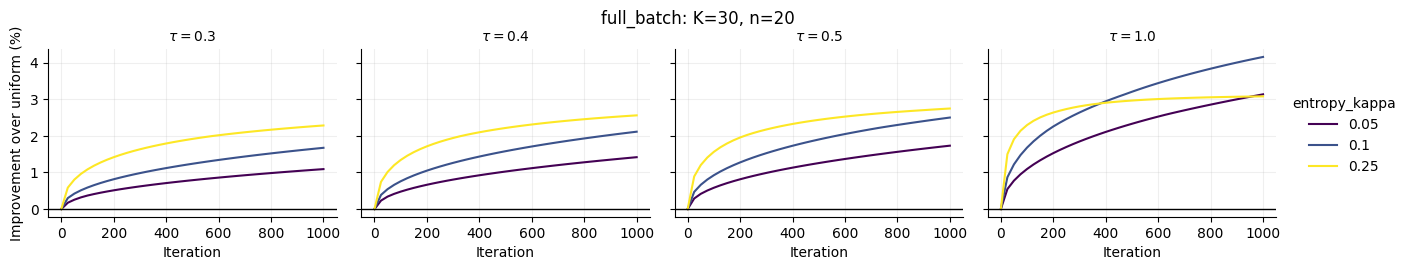

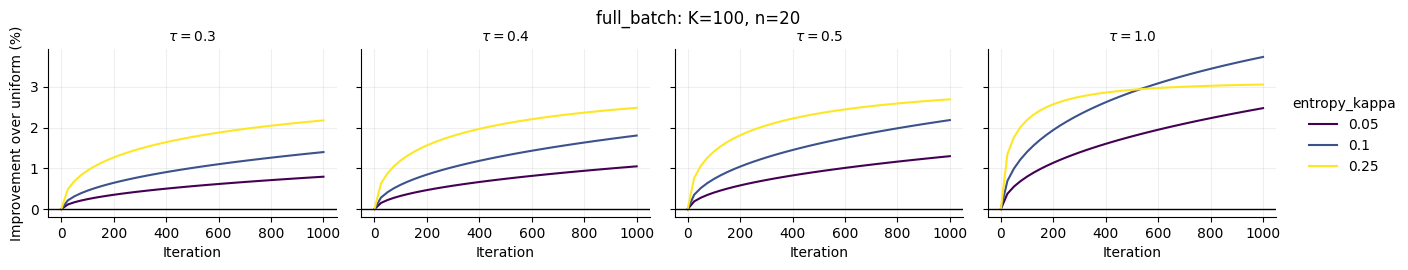

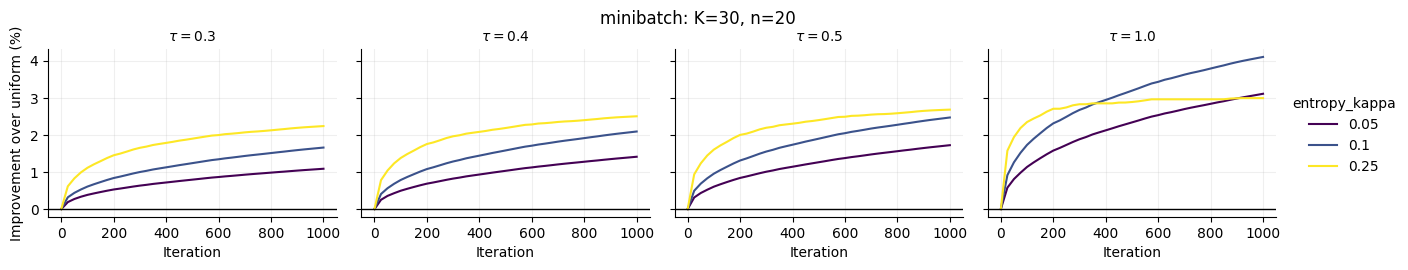

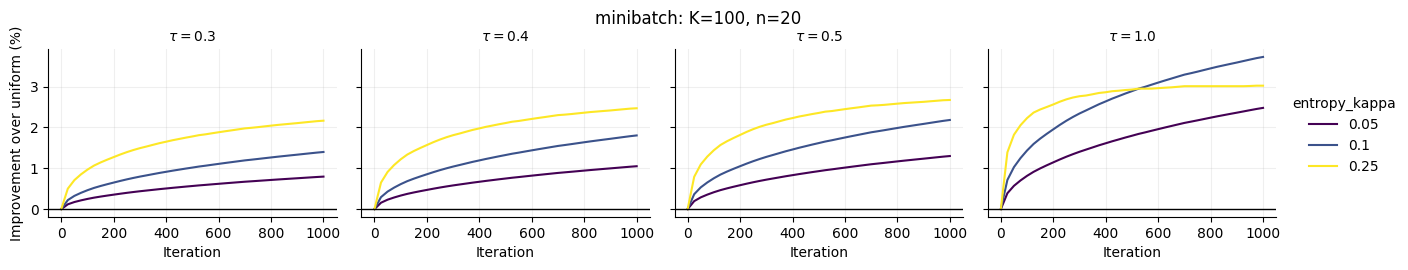

In [162]:
combinations = (
    history[["K", "n", "method"]].drop_duplicates().sort_values(["method", "K", "n"])
)

for row in combinations.itertuples(index=False):
    g = plot_eta_improvement(
        history,
        K=row.K,
        n=row.n,
        method=row.method,
    )
    if g is not None:
        plt.show()

In [165]:
def plot_eta_obj(history, K, n):

    h = history[(history["K"] == K) & (history["n"] == n)]
    g = sns.relplot(
        data=h,
        x="residual_norm",
        y="eta",
        row="entropy_kappa",
        # hue="smoothing_tau",
        style="method",
        col="step_size",
        kind="scatter",
        height=3.2,
    )

    for ax in plt.gcf().axes:
        ax.grid(alpha=0.2)

    g.set_titles(r"$\kappa={row_name}$, step_size=${col_name}$")
    g.fig.suptitle(f"K={K}, n={n}", y=1.02)

    plt.show()

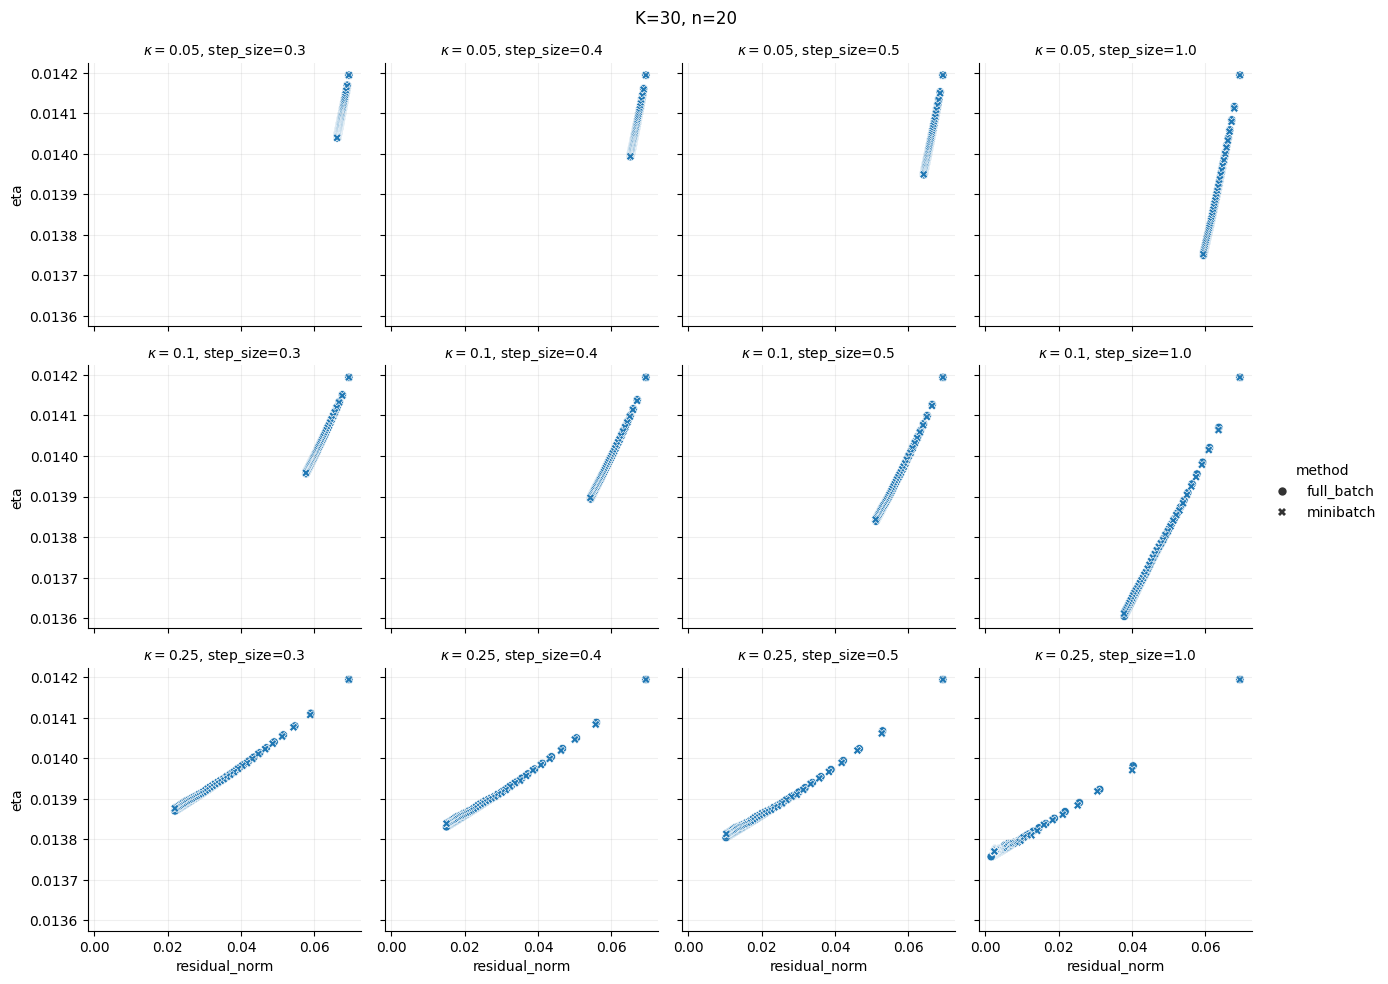

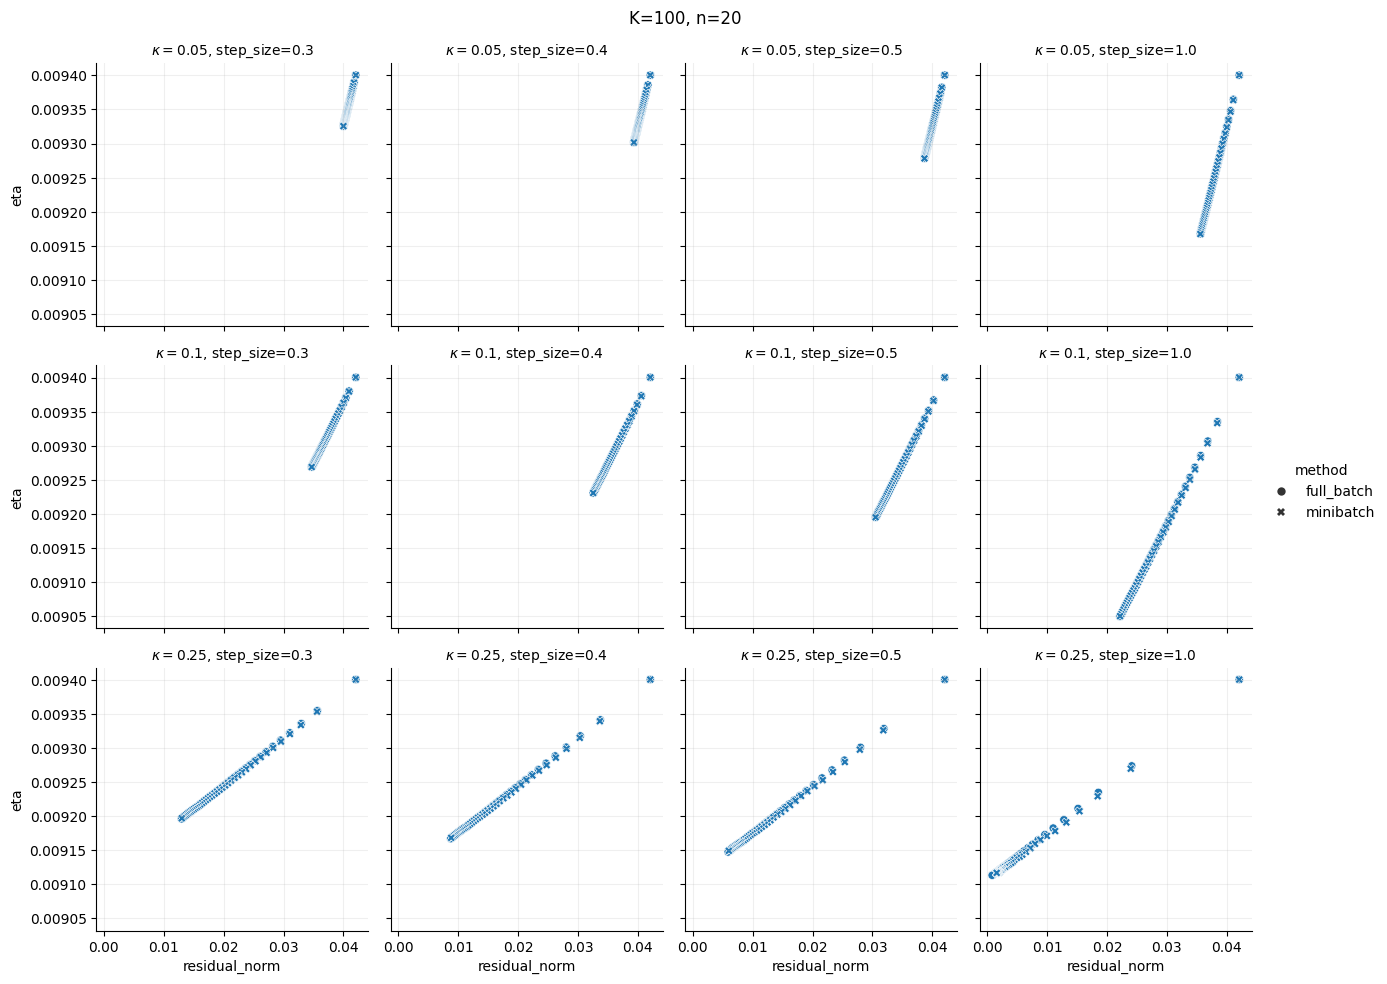

In [166]:
combinations = history[["K", "n"]].drop_duplicates().sort_values(["K", "n"])

for row in combinations.itertuples(index=False):
    g = plot_eta_obj(
        history,
        K=row.K,
        n=row.n,
    )
    if g is not None:
        plt.show()